In [3]:
%matplotlib inline

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import statsmodels.stats.multitest
from scipy.stats import spearmanr
import pingouin as pg


In [39]:
from scipy import stats
from scipy.stats import f_oneway

# Введение
Датасет "Spotify Most Streamed Songs" содержит информацию о всех популярных песнях, начиная с 1930 года и включает следующие колонки:

    track_name: Название трека
    artist(s)_name: Имя исполнителя
    artist_count: Количество исполнителей
    released_month: Год выпуска
    released_day: День выпуска
    in_spotify_playlists: Количество в плейлистах Spotify
    in_spotify_charts: Место в чартах Spotify
    streams: Количество стриминговой активности
    in_apple_playlists: Количество в плейлистах Apple Musik
    in_deezer_playlists: Количество в плейлистах Deezer
    in_shazam_charts: Количество в плейлистах Shazam
    Beats (bpm): Битов в минуту
    danceability(%): Оценка танцевальности песни
    energy(%): Оценка энергичности песни
    instrumentalness(%): Оценка инстументальности
    liveness(%): Оценка Live Performance элементов
    cover_url: Ссылка на каверы к песне


Проверим данные на предмет присутствия пропусков, выбросов и пр. Также немного преобразуем данные для более эффективного хранения памяти и удобного использования в будущем.


In [7]:
df = pd.read_csv('Spotify Most Streamed Songs.csv')

In [8]:
# Проверка на пропуски
print("Пропуски до обработки:")
print(df.isna().sum())

Пропуски до обработки:
track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  0
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        50
bpm                      0
key                     95
mode                     0
danceability_%           0
valence_%                0
energy_%                 0
acousticness_%           0
instrumentalness_%       0
liveness_%               0
speechiness_%            0
cover_url                0
dtype: int64


In [9]:
# Заполнение пропусков
df.update(df['in_shazam_charts'].fillna(df['in_shazam_charts'].mode()[0]))
df.update(df['key'].fillna(df['key'].mode()[0]))



In [10]:
# Проверка на пропуски после заполнения
print("Пропуски после обработки:")
print(df.isna().sum())

Пропуски после обработки:
track_name              0
artist(s)_name          0
artist_count            0
released_year           0
released_month          0
released_day            0
in_spotify_playlists    0
in_spotify_charts       0
streams                 0
in_apple_playlists      0
in_apple_charts         0
in_deezer_playlists     0
in_deezer_charts        0
in_shazam_charts        0
bpm                     0
key                     0
mode                    0
danceability_%          0
valence_%               0
energy_%                0
acousticness_%          0
instrumentalness_%      0
liveness_%              0
speechiness_%           0
cover_url               0
dtype: int64


Как видим, пропусков нет

In [11]:
df.isna().any().any()

False

In [12]:
# Преобразование данных
df['track_name'] = df['track_name'].astype('category')
df['artist(s)_name'] = df['artist(s)_name'].astype('category')
df['key'] = df['key'].astype('category')
df['mode'] = df['mode'].astype('category')

Посчитаем основные статистики:

In [13]:
# Основные статистики для категориальных признаков
print(df.select_dtypes('category').describe())

       track_name artist(s)_name  key   mode
count         953            953  953    953
unique        943            645   11      2
top       Flowers   Taylor Swift   C#  Major
freq            2             34  215    550


In [14]:
# Основные статистики для числовых признаков
print(df.describe())

       artist_count  released_year  released_month  released_day  \
count    953.000000     953.000000      953.000000    953.000000   
mean       1.556139    2018.238195        6.033578     13.930745   
std        0.893044      11.116218        3.566435      9.201949   
min        1.000000    1930.000000        1.000000      1.000000   
25%        1.000000    2020.000000        3.000000      6.000000   
50%        1.000000    2022.000000        6.000000     13.000000   
75%        2.000000    2022.000000        9.000000     22.000000   
max        8.000000    2023.000000       12.000000     31.000000   

       in_spotify_playlists  in_spotify_charts  in_apple_playlists  \
count            953.000000         953.000000          953.000000   
mean            5200.124869          12.009444           67.812172   
std             7897.608990          19.575992           86.441493   
min               31.000000           0.000000            0.000000   
25%              875.000000          

Построим тепловую карту для корреляций между числовыми признаками.

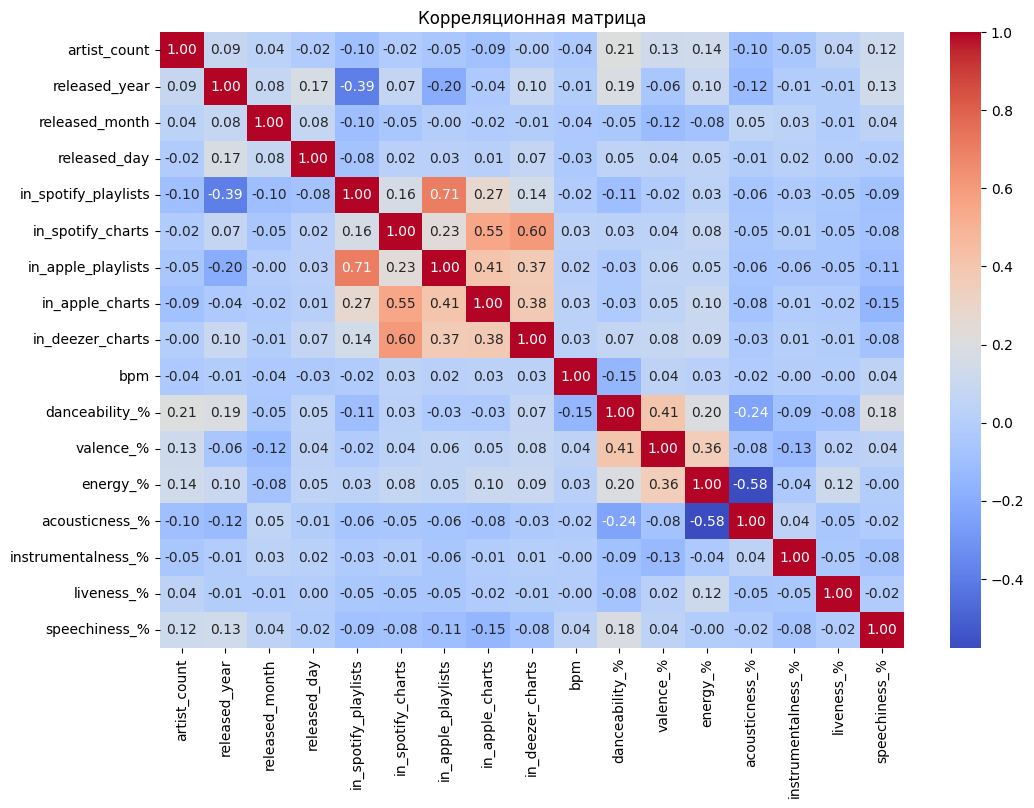

In [15]:
# Построение тепловой карты корреляций между числовыми признаками
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()

Заметим, что сильная связь наблюжается между песнями, которые находятся в топах в Apple Musik и Spotify. Сильная отрицательная связь между энергичностью песни и акустикой.

Посмотрим на распределения признаков:

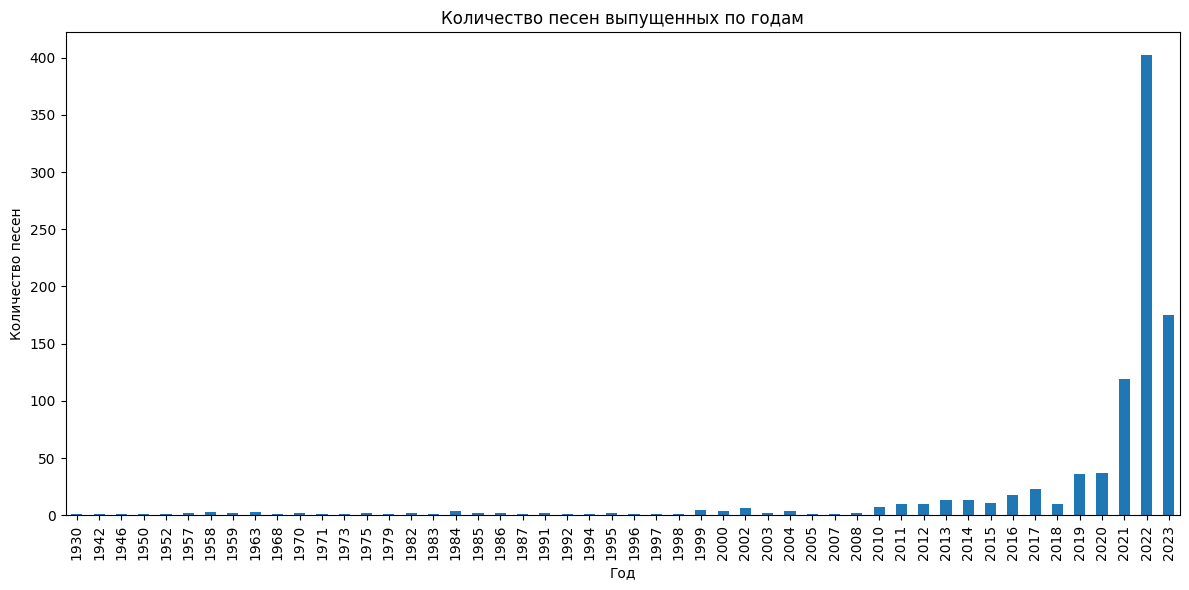

In [16]:
years_counts = df.groupby('released_year').size()

plt.figure(figsize=(12, 6))
years_counts.plot(kind='bar')

plt.title('Количество песен выпущенных по годам')
plt.xlabel('Год')
plt.ylabel('Количество песен')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Видим, что самые популярные песни были выпущены за последние 3 года, но несмотря на это песни прошлых лет и даже десятилетия пользуются спросом.


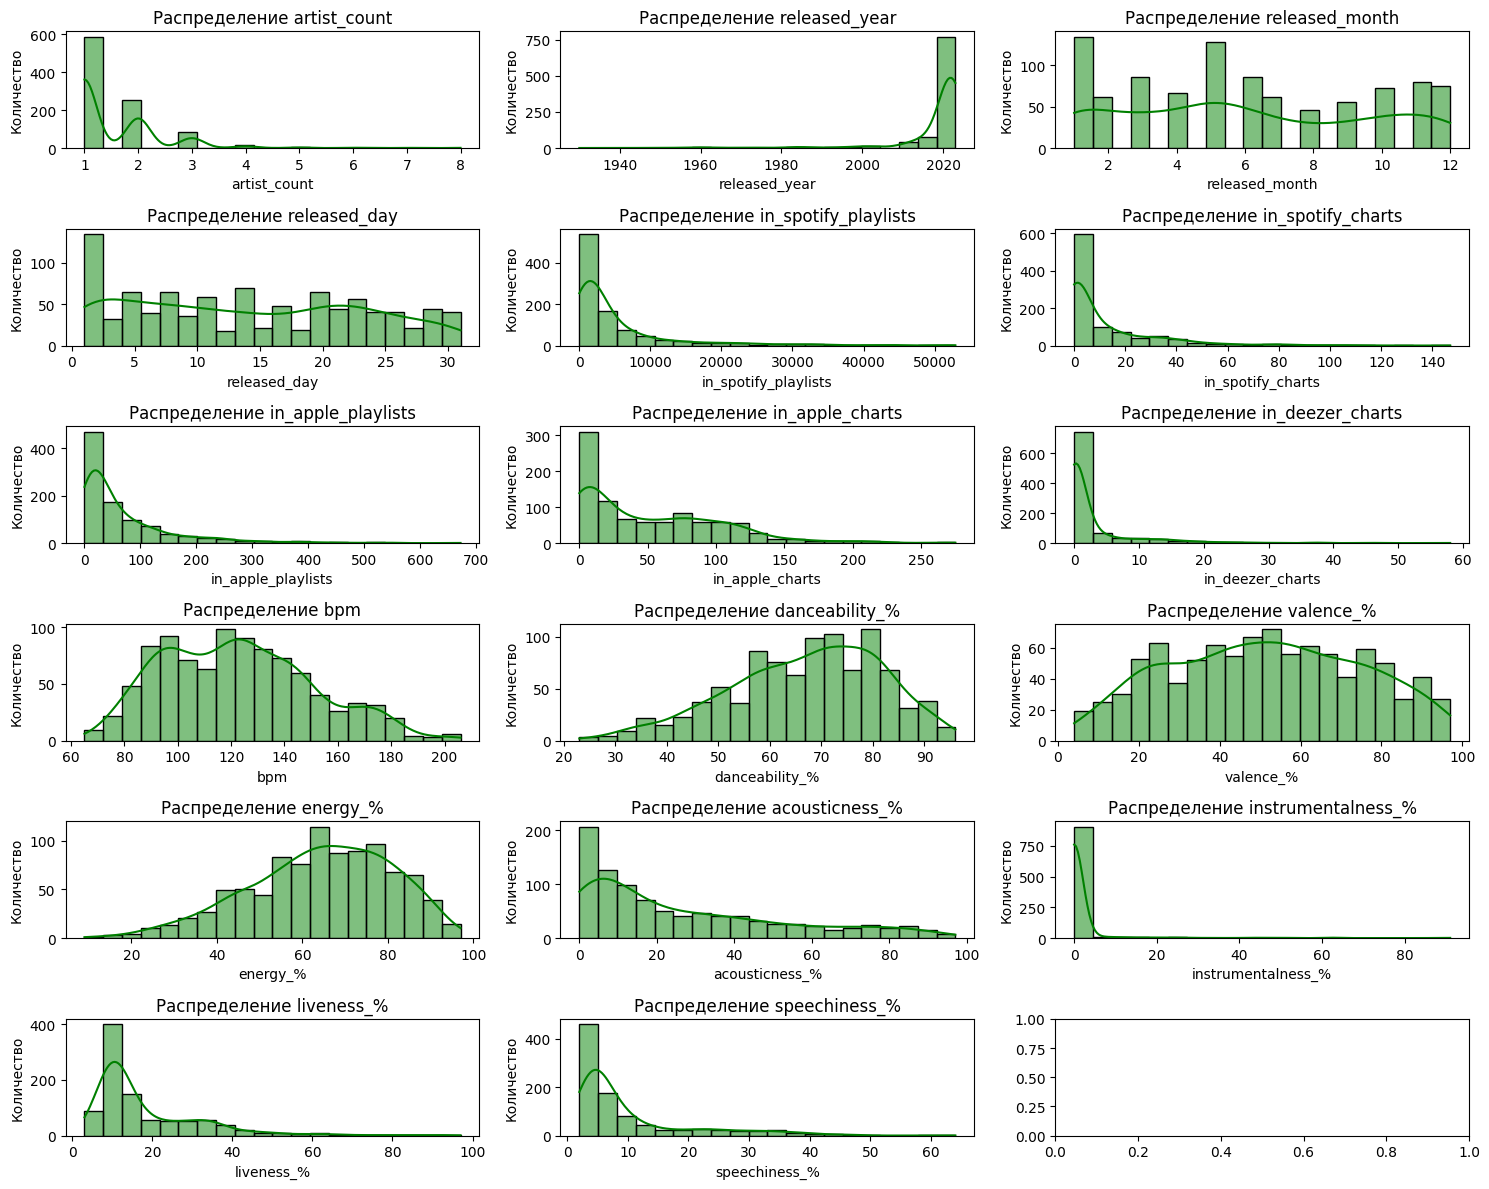

In [17]:
# Распределение числовых признаков
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
fig, axes = plt.subplots(len(num_cols) // 3 + (len(num_cols) % 3 > 0), 3, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], ax=ax, kde=True, bins=20, color='green')
    ax.set_title(f'Распределение {col}')
    ax.set_ylabel('Количество')

plt.tight_layout()
plt.show()

Визуализация категориальных данных:

<ipython-input-18-0fe96a608b53>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=ax, palette='Set2', hue=None)
<ipython-input-18-0fe96a608b53>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=ax, palette='Set2', hue=None)


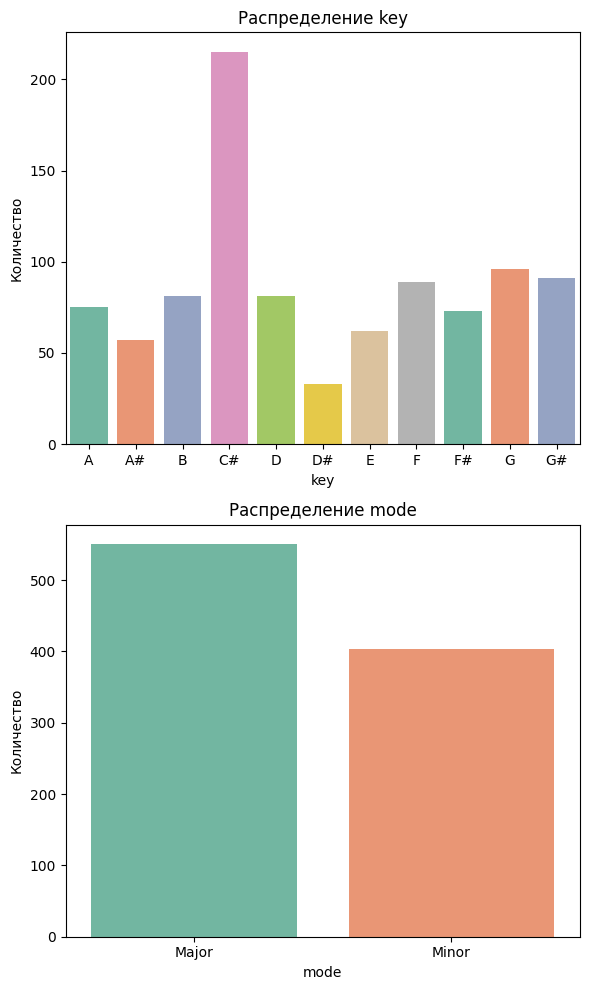

In [18]:
# Распределение категориальных признаков

# Выбор конкретных категориальных столбцов
selected_cols = ['key', 'mode']

# Создание подграфиков
fig, axes = plt.subplots(len(selected_cols), 1, figsize=(6, 5 * len(selected_cols)))
axes = axes.flatten()

for ax, col in zip(axes, selected_cols):
    sns.countplot(x=df[col], ax=ax, palette='Set2', hue=None)
    ax.set_title(f'Распределение {col}')
    ax.set_ylabel('Количество')

plt.tight_layout()
plt.show()

 # Использование Boxplot и Violinplot для анализа распределений
Для непрерывных переменных можно использовать boxplot для идентификации выбросов и violinplot для демонстрации плотности вероятности:

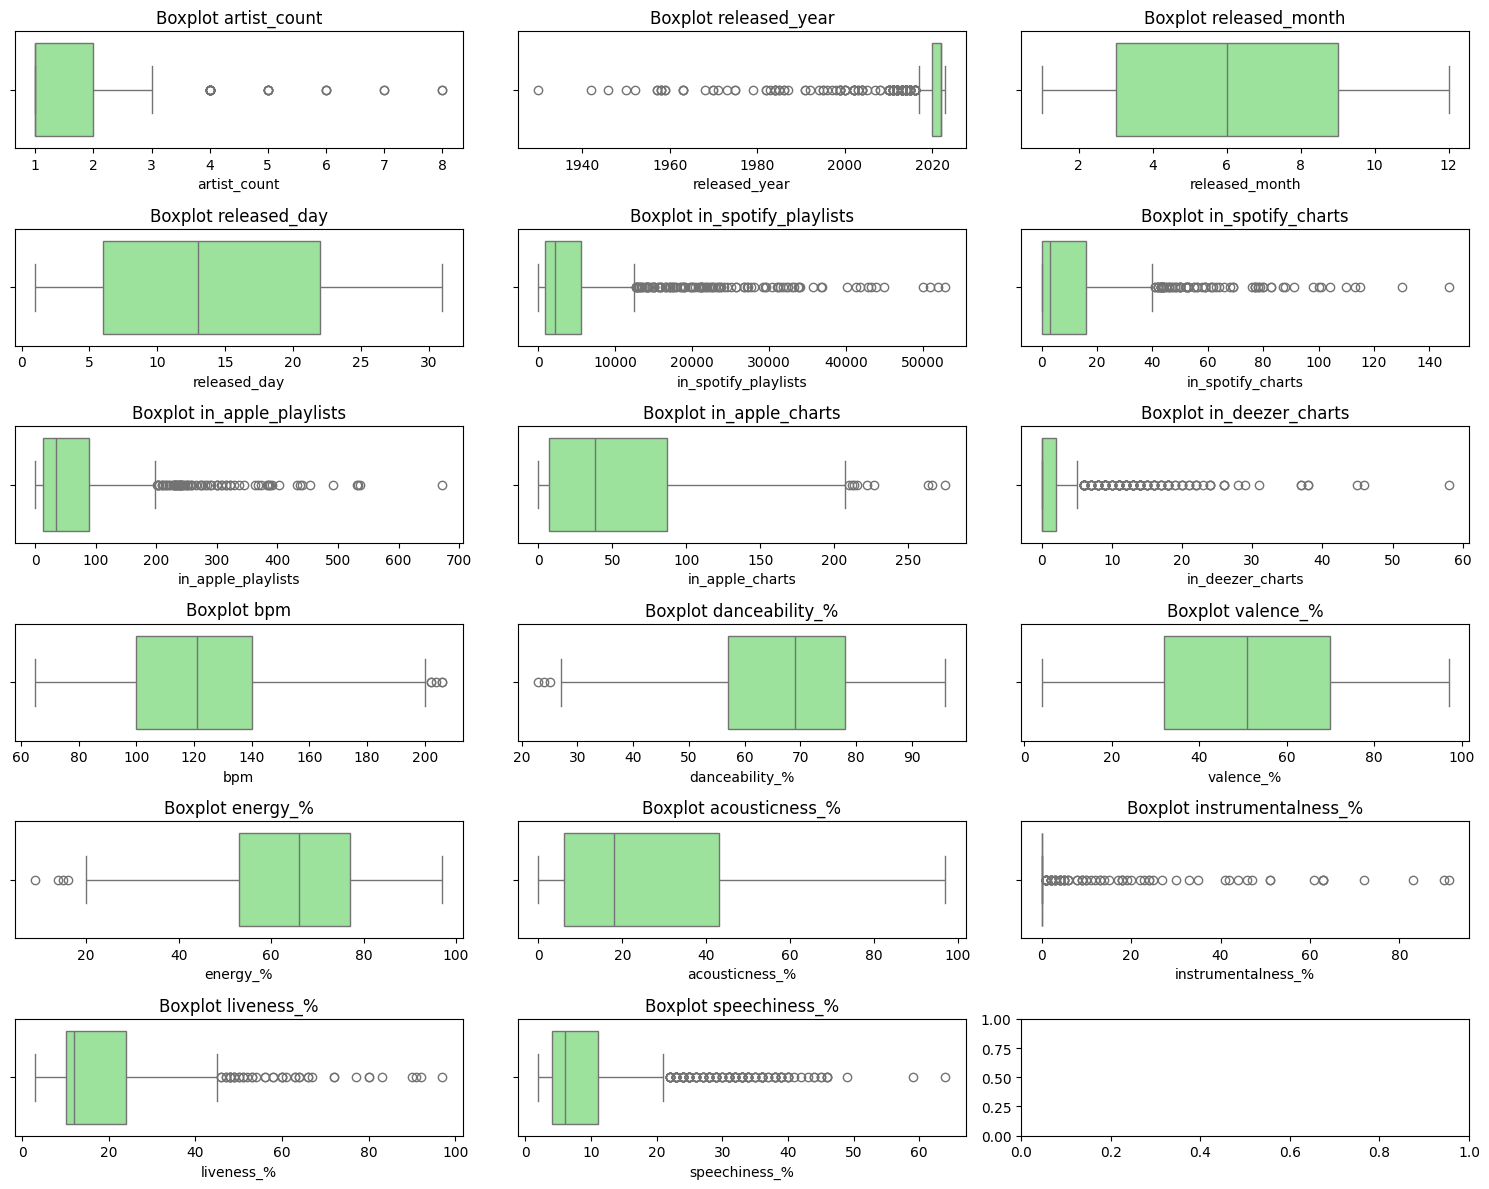

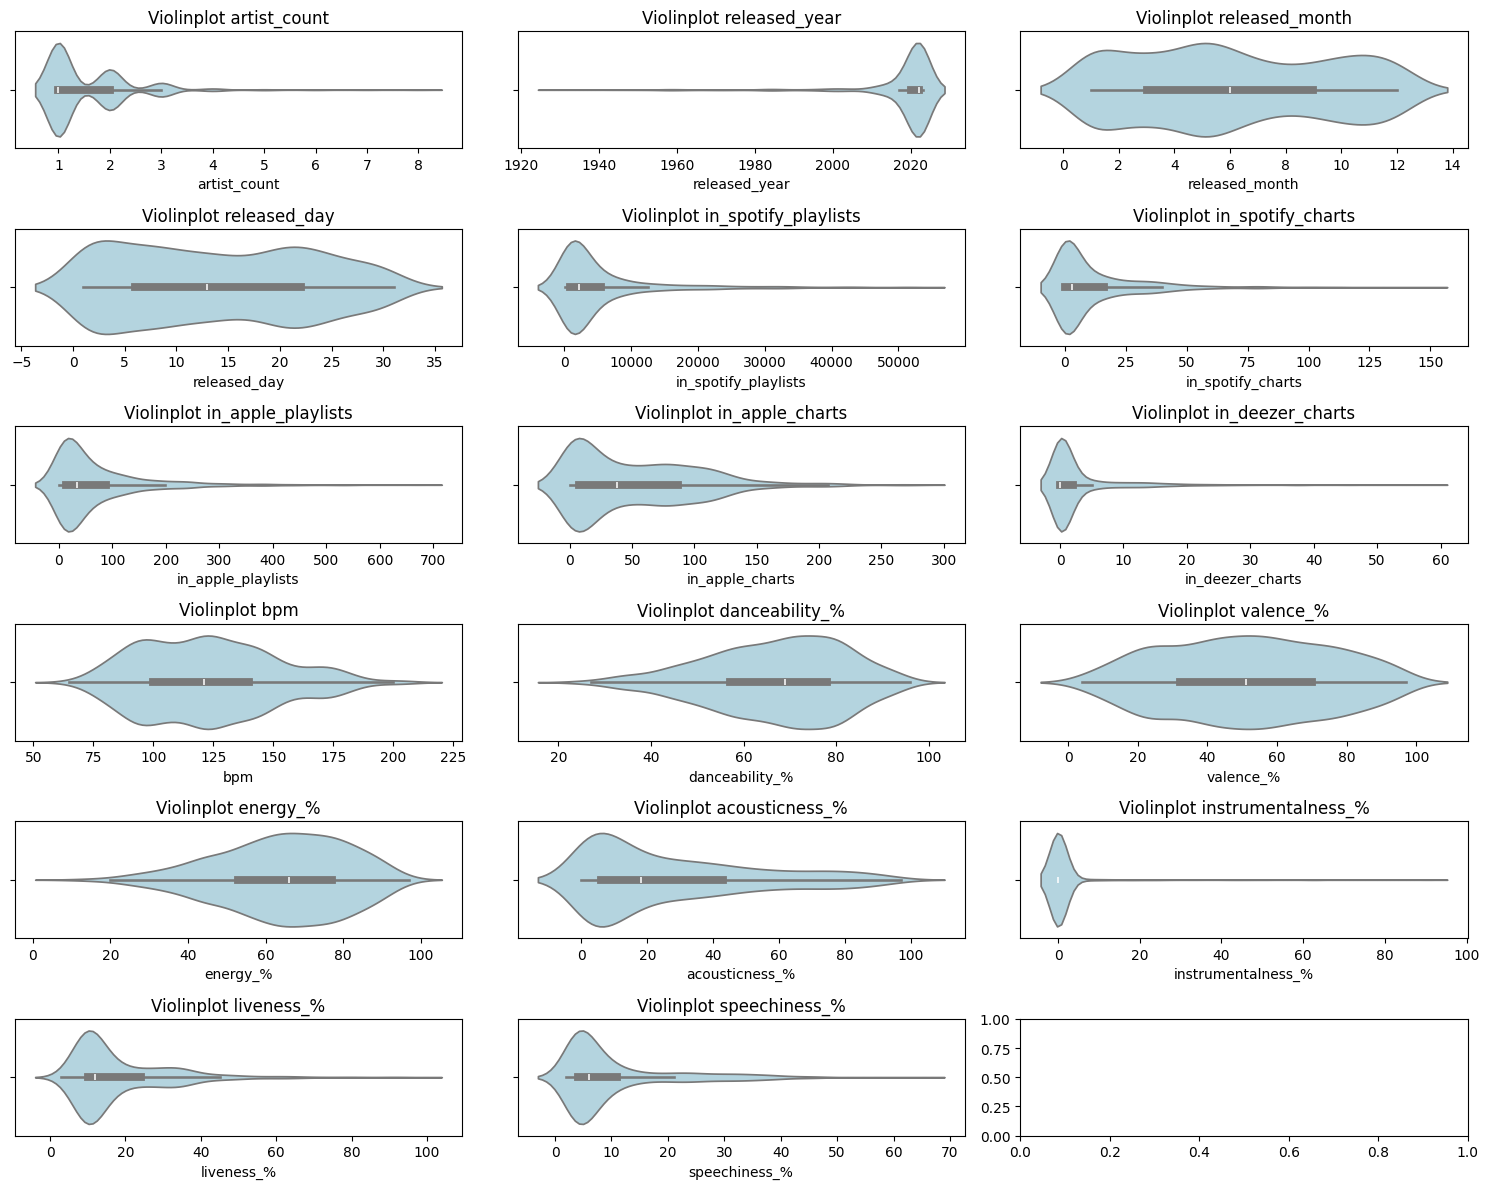

In [19]:
# Boxplot для числовых признаков
fig, axes = plt.subplots(len(num_cols) // 3 + (len(num_cols) % 3 > 0), 3, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col], ax=ax, color='lightgreen')
    ax.set_title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

# Violinplot для числовых признаков
fig, axes = plt.subplots(len(num_cols) // 3 + (len(num_cols) % 3 > 0), 3, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.violinplot(x=df[col], ax=ax, color='lightblue')
    ax.set_title(f'Violinplot {col}')

plt.tight_layout()
plt.show()

 # Парные взаимосвязи между признаками
 Использование pairplot может помочь визуализировать попарные отношения между признаками, особенно для анализа взаимосвязей:

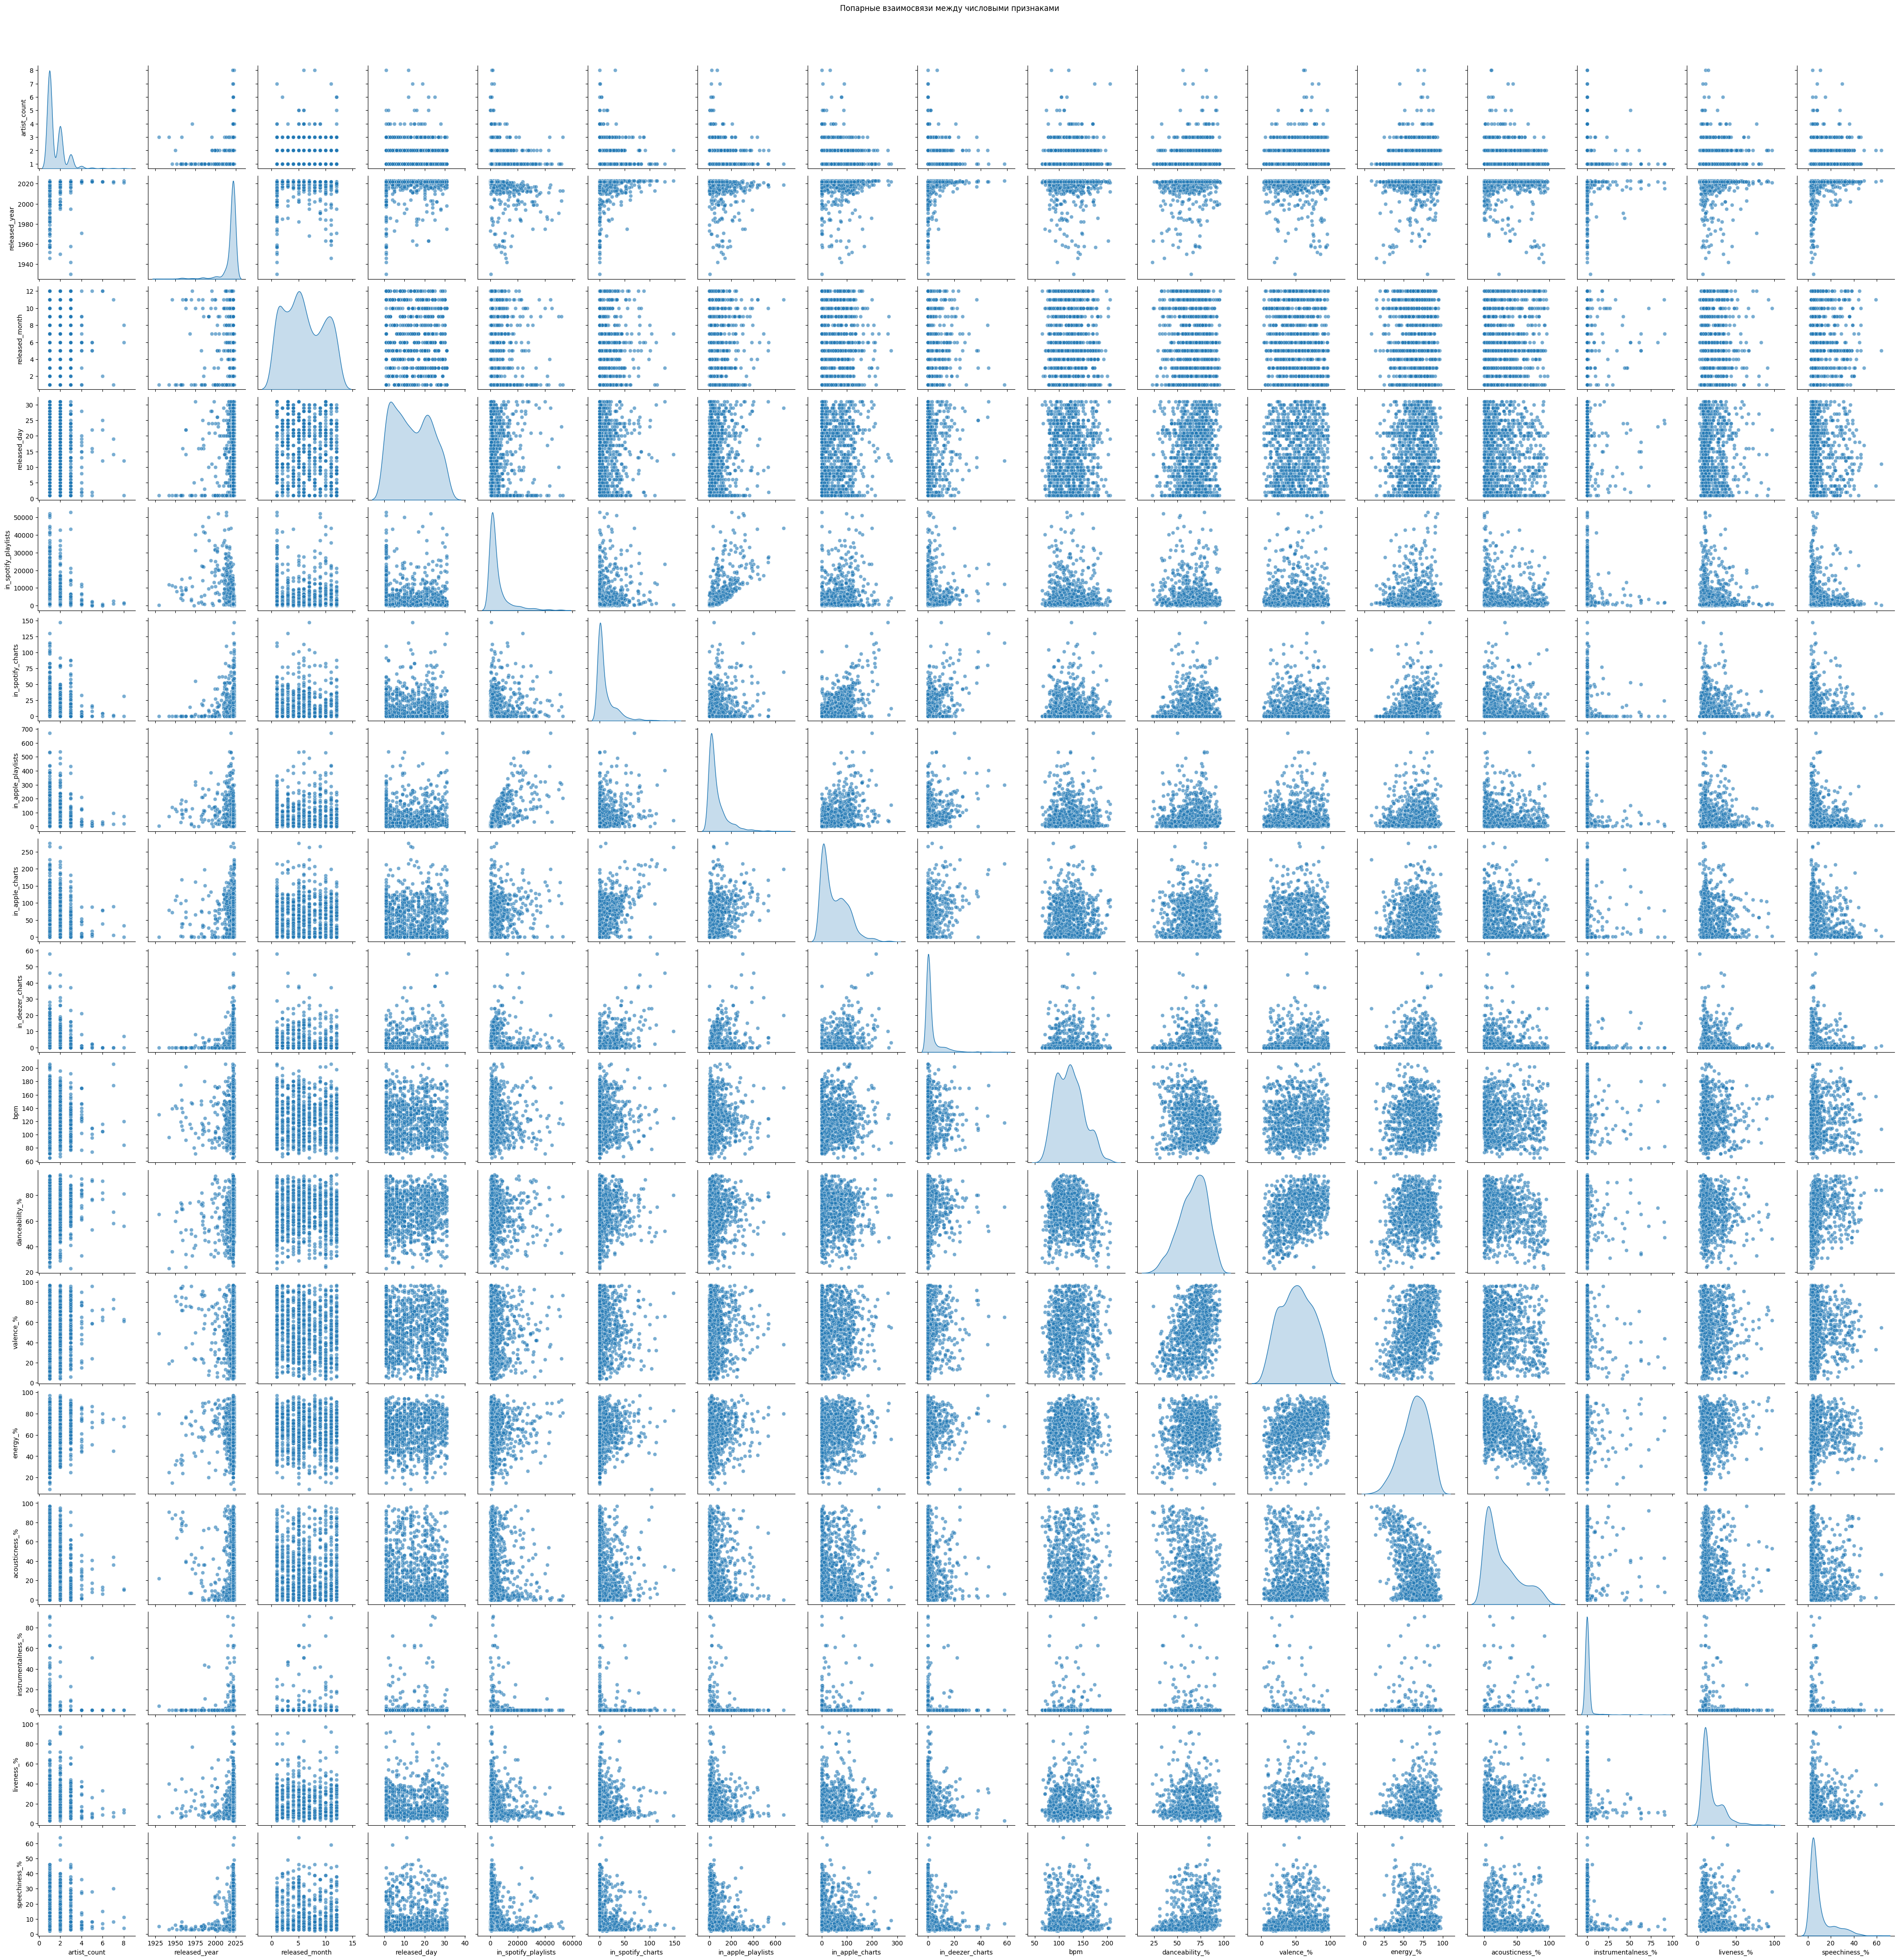

In [32]:
# Pairplot для числовых признаков
sns.pairplot(df[num_cols], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle("Попарные взаимосвязи между числовыми признаками", y=1.02)
plt.show()

# Сформируем гипотезы:
- Стриминговая активность песен различается в зависимости от их лада.
- Количество исполнителей влияет на успех песни.
- Популярность песен на разных платформах не отличается.
- Атрибуты песен влияют на ее популярность.
- Дата выхода песни влияет на ее популярность.


# Гипотеза 1: Стриминговая активность песен различается в зависимости от их лада

Сначала визуализируем распределение стриминговой активности песен в зависимости от лада и затем проведём t-test.

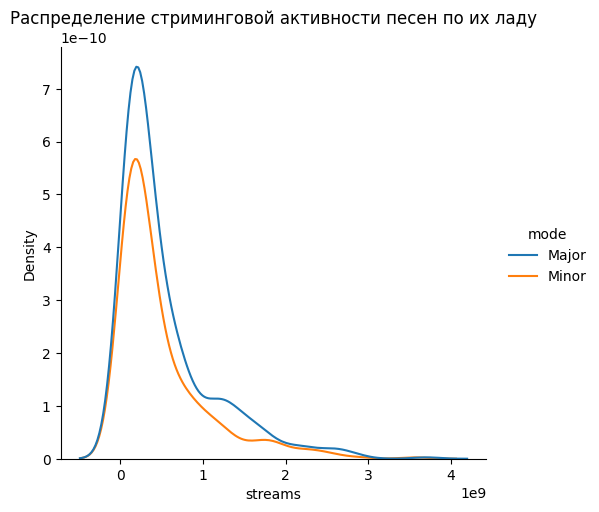

In [20]:
# Визуализация распределения стриминговой активности песен по их ладу

# Убедимся, что 'streams' является числовым типом
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

sns.displot(data=df, x='streams', hue='mode', kind='kde')
plt.title('Распределение стриминговой активности песен по их ладу')
plt.show()

In [21]:
# Сгруппируем по ладу песни и посчитаем средную стриминговую активность песен для каждого из них
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
mean_songs_streams = df[['streams', 'mode']].groupby('mode').mean()
print(mean_songs_streams)


            streams
mode               
Major  5.348328e+08
Minor  4.859445e+08


<ipython-input-21-44387230a1f9>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_songs_streams = df[['streams', 'mode']].groupby('mode').mean()


In [22]:
# T-test для оценки разницы стриминговой активности для песен в зависимости от лада

# Преобразование в числовой тип
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

# Фильтрация данных по ладу
major_songs = df[df['mode'] == 'Major']['streams']
minor_songs = df[df['mode'] == 'Minor']['streams']

# Удаление NaN значений
major_songs = major_songs.dropna()
minor_songs = minor_songs.dropna()

# Выполнение t-теста
if len(major_songs) > 0 and len(minor_songs) > 0:
    t_stat, p_val = stats.ttest_ind(major_songs, minor_songs)
    print(f"T-statistic: {t_stat}, P-value: {p_val}")

    if p_val < 0.05:
        print("Различие статистически значимо.")
    else:
        print("Различие не является статистически значимым.")
else:
    print("Недостаточно данных для выполнения t-теста.")


T-statistic: 1.3152806250107634, P-value: 0.1887329698746361
Различие не является статистически значимым.


Различие в стриминговой активности между веселыми и траурными песнями статистически не значимо, так как P-value меньше 0.05. Это указывает на то, что средняя стриминговая активность песен не зависит от их лада.

# Гипотеза 2: Количество исполнителей влияет на успех песни.
Проверим зависимость стриминговой активности от количества исполнителец.


<ipython-input-23-75314f6e5e91>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=artist_grouped, x="artist_count", y="streams", palette="viridis", hue=None)


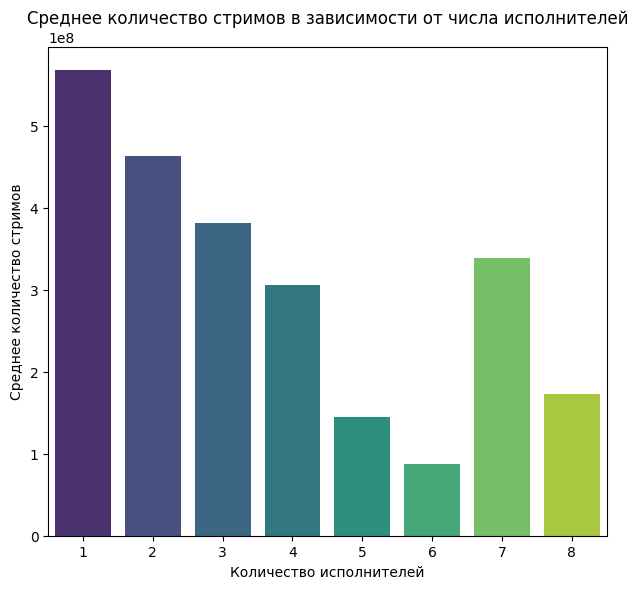

In [23]:
# Группируем данные по количеству исполнителей
artist_grouped = df.groupby("artist_count")[["streams", "in_spotify_charts"]].mean().reset_index()

# Визуализация средних значений стримов и позиций в чартах
plt.figure(figsize=(12, 6))

# График для streams
plt.subplot(1, 2, 1)
sns.barplot(data=artist_grouped, x="artist_count", y="streams", palette="viridis", hue=None)
plt.title("Среднее количество стримов в зависимости от числа исполнителей")
plt.xlabel("Количество исполнителей")
plt.ylabel("Среднее количество стримов")

plt.tight_layout()
plt.show()

<ipython-input-24-1abbafb1f760>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=artist_grouped, x="artist_count", y="in_spotify_charts", palette="magma", hue=None)


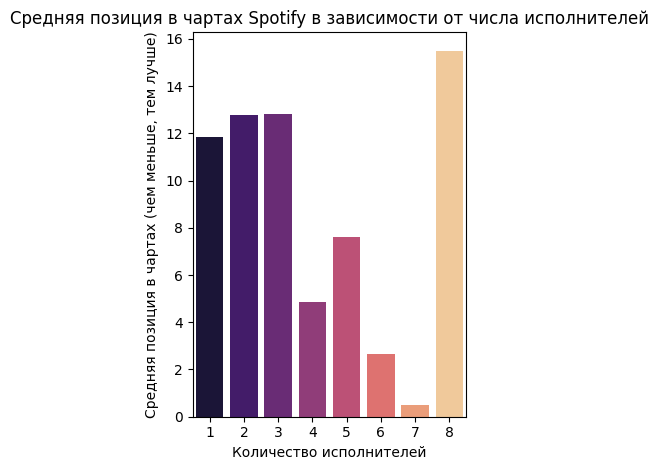

In [24]:
# График для in_spotify_charts
plt.subplot(1, 2, 2)
sns.barplot(data=artist_grouped, x="artist_count", y="in_spotify_charts", palette="magma", hue=None)
plt.title("Средняя позиция в чартах Spotify в зависимости от числа исполнителей")
plt.xlabel("Количество исполнителей")
plt.ylabel("Средняя позиция в чартах (чем меньше, тем лучше)")

plt.tight_layout()
plt.show()

In [25]:
# Статистический тест ANOVA для сравнения групп
# ANOVA проверяет, есть ли значимые различия между группами по среднему
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
grouped_streams = [df[df["artist_count"] == count]["streams"].dropna()  for count in df["artist_count"].unique()]
anova_result_streams = f_oneway(*grouped_streams)
print(f"ANOVA для streams: p-value = {anova_result_streams.pvalue}")

grouped_charts = [df[df["artist_count"] == count]["in_spotify_charts"] for count in df["artist_count"].unique()]
anova_result_charts = f_oneway(*grouped_charts)
print(f"ANOVA для in_spotify_charts: p-value = {anova_result_charts.pvalue}")

# Интерпретация результатов
if anova_result_streams.pvalue < 0.05:
    print("Различия в средних значениях streams статистически значимы.")
else:
    print("Различия в средних значениях streams не являются статистически значимыми.")

if anova_result_charts.pvalue < 0.05:
    print("Различия в средних позициях in_spotify_charts статистически значимы.")
else:
    print("Различия в средних позициях in_spotify_charts не являются статистически значимыми.")

ANOVA для streams: p-value = 0.00830546021135064
ANOVA для in_spotify_charts: p-value = 0.7505201809203133
Различия в средних значениях streams статистически значимы.
Различия в средних позициях in_spotify_charts не являются статистически значимыми.


Видим, что зависимость в средних значениях стримингах от количества исполнителей статистически значимо, однако менее значимо для позициях на стриминговом сервесе Spotify.

# Гипотеза 3: Популярность песен на разных платформах не отличается.
Анализируем взаимосвязь популярность песен между платформами.

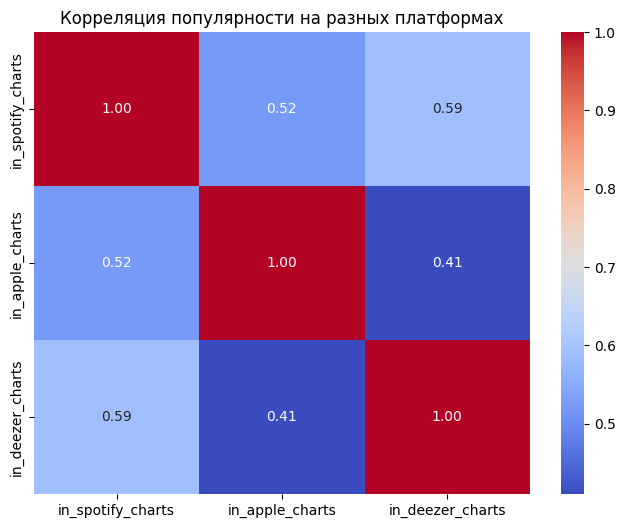

In [28]:
# Уберём строки с пропущенными значениями в метриках для платформ (если такие есть)
data = df.dropna(subset=['in_spotify_charts', 'in_apple_charts', 'in_deezer_charts'])

# Визуализация корреляций между платформами
plt.figure(figsize=(8, 6))
sns.heatmap(data[['in_spotify_charts', 'in_apple_charts', 'in_deezer_charts']].corr(method='spearman'),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляция популярности на разных платформах')
plt.show()

In [29]:
# Вычислим ранговую корреляцию Спирмена для каждой пары платформ
spotify_apple_corr, spotify_apple_pval = spearmanr(data['in_spotify_charts'], data['in_apple_charts'])
spotify_deezer_corr, spotify_deezer_pval = spearmanr(data['in_spotify_charts'], data['in_deezer_charts'])
apple_deezer_corr, apple_deezer_pval = spearmanr(data['in_apple_charts'], data['in_deezer_charts'])

# Вычисление корреляции Спирмена с использованием pingouin
spotify_apple_pg = pg.corr(data['in_spotify_charts'], data['in_apple_charts'], method='spearman')
spotify_deezer_pg = pg.corr(data['in_spotify_charts'], data['in_deezer_charts'], method='spearman')
apple_deezer_pg = pg.corr(data['in_apple_charts'], data['in_deezer_charts'], method='spearman')


# Вывод результатов
print(f"Корреляция между Spotify и Apple Music: коэффициент = {spotify_apple_corr:.2f}, p-value = {spotify_apple_pg['p-val'].values[0]}")
print(f"Корреляция между Spotify и Deezer: коэффициент = {spotify_deezer_corr:.2f}, p-value = {spotify_deezer_pg['p-val'].values[0]}")
print(f"Корреляция между Apple Music и Deezer: коэффициент = {apple_deezer_corr:.2f}, p-value = {apple_deezer_pg['p-val'].values[0]}")


# Интерпретация результатов
if spotify_apple_pg['p-val'].values[0] < 0.05:
    print("Связь между популярностью в Spotify и Apple Music статистически значима.")
else:
    print("Связь между популярностью в Spotify и Apple Music не является статистически значимой.")

if spotify_deezer_pg['p-val'].values[0] < 0.05:
    print("Связь между популярностью в Spotify и Deezer статистически значима.")
else:
    print("Связь между популярностью в Spotify и Deezer не является статистически значимой.")

if apple_deezer_pg['p-val'].values[0] < 0.05:
    print("Связь между популярностью в Apple Music и Deezer статистически значима.")
else:
    print("Связь между популярностью в Apple Music и Deezer не является статистически значимой.")

Корреляция между Spotify и Apple Music: коэффициент = 0.52, p-value = 1.7392648428685148e-67
Корреляция между Spotify и Deezer: коэффициент = 0.59, p-value = 4.868132172329094e-90
Корреляция между Apple Music и Deezer: коэффициент = 0.41, p-value = 5.738917789022724e-40
Связь между популярностью в Spotify и Apple Music статистически значима.
Связь между популярностью в Spotify и Deezer статистически значима.
Связь между популярностью в Apple Music и Deezer статистически значима.


Наблюдается положительная корреляция популярности песен между различными стриминговыми платформами и достигает (0.59). Очень низкая статистическая значимость указывает на то, что популярность песен на различных платформах значительна.

# Гипотеза 4: Атрибуты песен влияют на ее популярность.
Исследуем взаимосвязь между характеристиками песни и ее успеху.

<ipython-input-40-eb27f2a26409>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='is_top', y=feature, palette='Set2', hue=None)
<ipython-input-40-eb27f2a26409>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='is_top', y=feature, palette='Set2', hue=None)
<ipython-input-40-eb27f2a26409>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='is_top', y=feature, palette='Set2', hue=None)
<ipython-input-40-eb27f2a26409>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be 

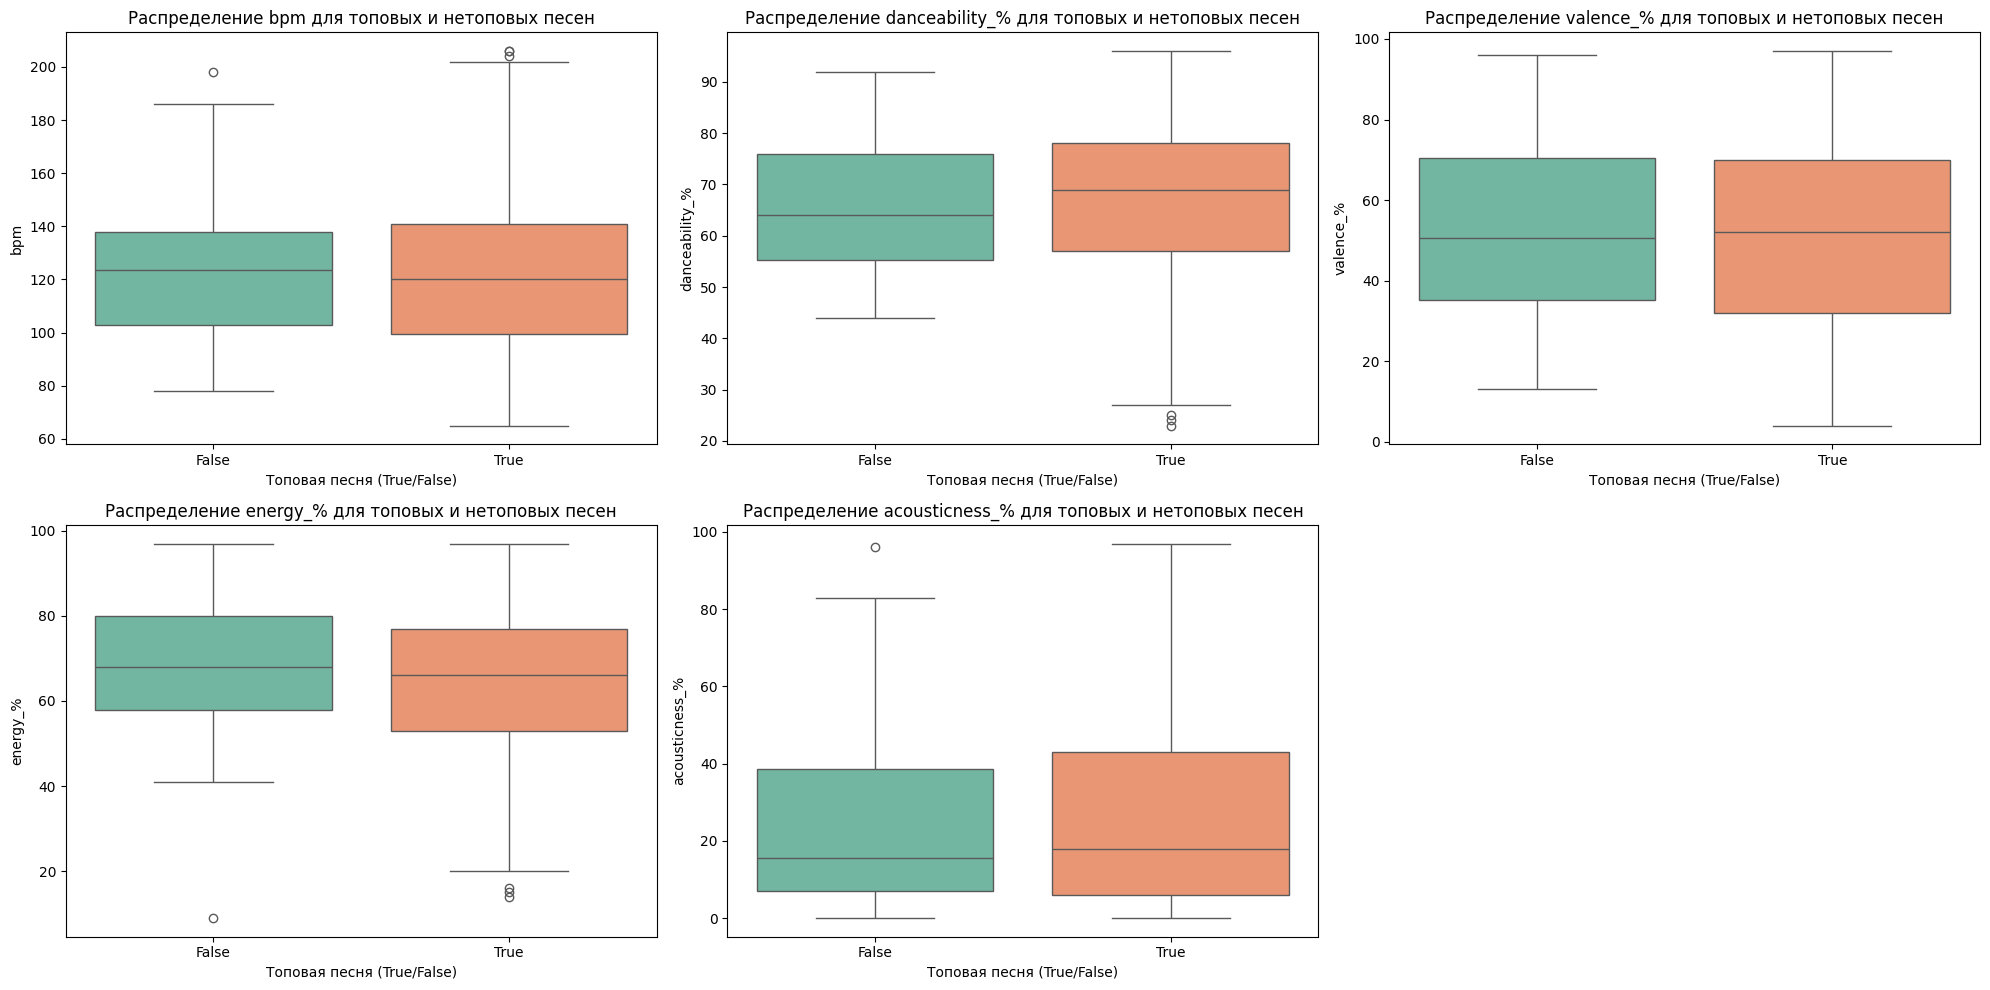

In [40]:
# Импортируем необходимые библиотеки
from scipy.stats import ttest_ind

# Определяем топовые песни (например, песни с позициями в чартах <= 50 считаем топовыми)
top_threshold = 50
data['is_top'] = data['in_spotify_charts'] <= top_threshold

# Музыкальные характеристики для анализа
features = ['bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%']

# Визуализация распределения музыкальных характеристик для топовых и нетоповых песен
plt.figure(figsize=(20, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=data, x='is_top', y=feature, palette='Set2', hue=None)
    plt.title(f'Распределение {feature} для топовых и нетоповых песен')
    plt.xlabel('Топовая песня (True/False)')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()


In [31]:
# Статистический тест (t-тест) для каждой музыкальной характеристики
for feature in features:
    top_values = data[data['is_top']][feature].dropna()
    non_top_values = data[~data['is_top']][feature].dropna()
    t_stat, p_val = ttest_ind(top_values, non_top_values)

    print(f"{feature}: t-stat = {t_stat:.2f}, p-value = {p_val:.4f}")
    if p_val < 0.05:
        print(f"Для {feature} различия между топовыми и нетоповыми песнями статистически значимы.")
    else:
        print(f"Для {feature} различия между топовыми и нетоповыми песнями не являются статистически значимыми.")

bpm: t-stat = -0.20, p-value = 0.8416
Для bpm различия между топовыми и нетоповыми песнями не являются статистически значимыми.
danceability_%: t-stat = 0.81, p-value = 0.4171
Для danceability_% различия между топовыми и нетоповыми песнями не являются статистически значимыми.
valence_%: t-stat = -0.21, p-value = 0.8361
Для valence_% различия между топовыми и нетоповыми песнями не являются статистически значимыми.
energy_%: t-stat = -1.09, p-value = 0.2768
Для energy_% различия между топовыми и нетоповыми песнями не являются статистически значимыми.
acousticness_%: t-stat = 0.65, p-value = 0.5165
Для acousticness_% различия между топовыми и нетоповыми песнями не являются статистически значимыми.


Наблюдаются статистически незначимые различия между влиянием атрибутов песен на их популярность. Это указывает на то, что атрибуты песни не влияют на успех песни.

# Гипотеза 5: Дата выхода песни влияет на ее популярность
Для этой гипотезы используем корреляцию Спирмана, чтобы определить влияние фактора времени на популярность песни.

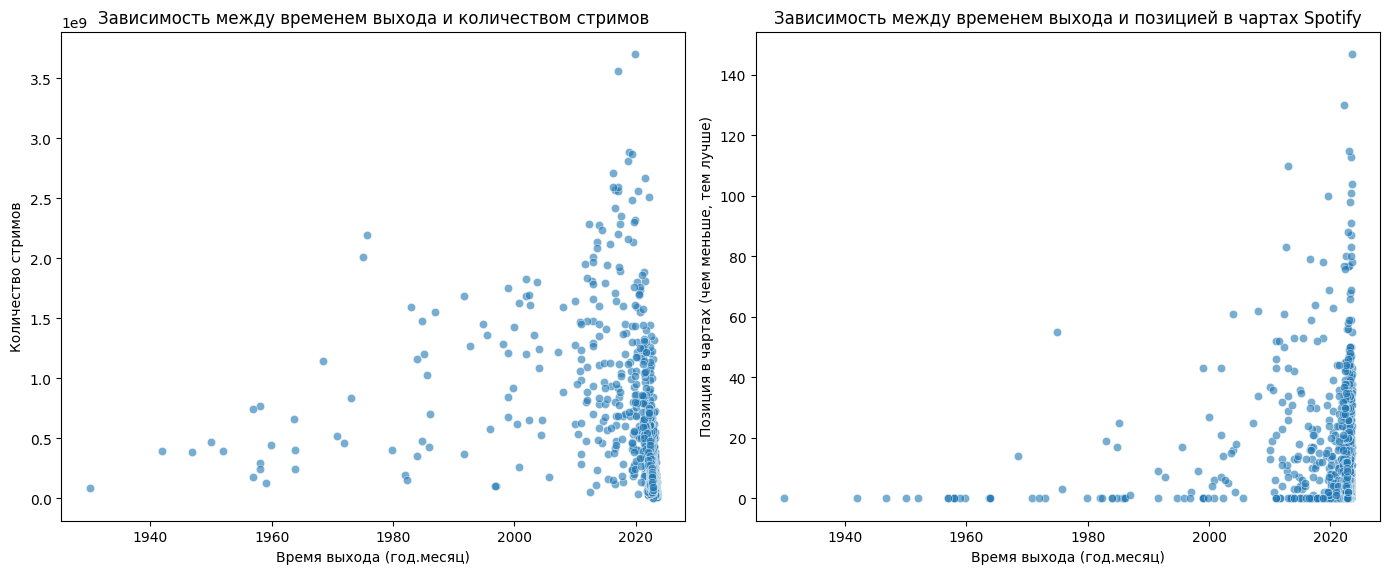

In [36]:
# Преобразование даты выпуска песни в единую временную метрику (например, год + месяц)
# Пример: 2023-07 -> 2023.58 (где 07/12 ≈ 0.58)
df['release_date_metric'] = df['released_year'] + (df['released_month'] - 1) / 12

# Визуализация популярности в зависимости от времени выхода
plt.figure(figsize=(14, 6))

df.dropna(subset=['streams', 'in_spotify_charts'], inplace=True)
# График зависимости между временем выхода и количеством стримов
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='release_date_metric', y='streams', alpha=0.6)
plt.title('Зависимость между временем выхода и количеством стримов')
plt.xlabel('Время выхода (год.месяц)')
plt.ylabel('Количество стримов')

# График зависимости между временем выхода и позицией в чартах Spotify
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='release_date_metric', y='in_spotify_charts', alpha=0.6)
plt.title('Зависимость между временем выхода и позицией в чартах Spotify')
plt.xlabel('Время выхода (год.месяц)')
plt.ylabel('Позиция в чартах (чем меньше, тем лучше)')

plt.tight_layout()
plt.show()

In [37]:
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
df['in_spotify_charts'] = pd.to_numeric(df['in_spotify_charts'], errors='coerce')
# Корреляционный анализ (используем ранговую корреляцию Спирмена, так как данные могут быть не линейны)
streams_corr, streams_pval = spearmanr(df['release_date_metric'], df['streams'])
charts_corr, charts_pval = spearmanr(df['release_date_metric'], df['in_spotify_charts'])
# Вычисление корреляции Спирмена с использованием pingouin
streams_pg = pg.corr(df['release_date_metric'], df['streams'], method='spearman')
charts_pg = pg.corr(df['release_date_metric'], df['in_spotify_charts'], method='spearman')


# Вывод результатов
print(f"Корреляция времени выхода и количества стримов: коэффициент = {streams_corr:.2f}, p-value = {streams_pg['p-val'].values[0]}")
print(f"Корреляция времени выхода и позиций в чартах: коэффициент = {charts_corr:.2f}, p-value = {charts_pg['p-val'].values[0]}")

# print(f"Корреляция времени выхода и количества стримов: коэффициент = {streams_corr:.2f}, p-value = {streams_pval:.4f}")
# print(f"Корреляция времени выхода и позиций в чартах: коэффициент = {charts_corr:.2f}, p-value = {charts_pval:.4f}")

# Интерпретация результатов
if streams_pg['p-val'].values[0] < 0.05:
    print("Зависимость между временем выхода и количеством стримов статистически значима.")
else:
    print("Зависимость между временем выхода и количеством стримов не является статистически значимой.")

if charts_pg['p-val'].values[0] < 0.05:
    print("Зависимость между временем выхода и позициями в чартах статистически значима.")
else:
    print("Зависимость между временем выхода и позициями в чартах не является статистически значимой.")


Корреляция времени выхода и количества стримов: коэффициент = -0.67, p-value = 2.1933193285943903e-125
Корреляция времени выхода и позиций в чартах: коэффициент = 0.18, p-value = 2.460007923312027e-08
Зависимость между временем выхода и количеством стримов статистически значима.
Зависимость между временем выхода и позициями в чартах статистически значима.


Наблюдаются статистически значимые различия в популярности песни от даты ее релиза, основанных на количестве стримов и позиции в чартах (P-value: 2.46e-08). Это указывает на то, что дата выхода влияет на популярность песни.

# Общий Вывод

Анализ данных о популярности песни показал следующее:

1. Лад песни практически не влияет на ее успех.
2. Количество исполнителей действительно влияет на успех песни и на ее стриминговые прослушивания.
3. Популярность песни не варьируется и не преобладает на какой-то конкретной стриминговой платформе, что указывает на то, что успешные треки популярны везде.
4. Атрибуты песни не оказывают сильного влияния на успех трека, что свидетельствует о том, что существуют другие факторы, которые демонстрируют большее влияние.
5. Дата релиза песни оказывает значительное влияние и указывает на то, что более новые песни, благодаря возросшей раскрутке на стиминговых платформах, показывают более лучшие результаты.

Эти результаты исследования подчеркивают важность правильной оценки факторов, чтобы трек преодолел все барьеры и стал хитом. Дата релиза, продвижение на всех стриминговых платформах и популярность артиста помогут оценить и спрогнозировать успех песни.
